# Multiplicative Constant Ablation: Figure 4 Right

This notebook reproduces the right panel of report Figure 4, where the hierarchy strength is varied through the teacher multiplicative constant `m`.


In [1]:
from analysis.utils import differing_config, fetch_runs, get_runs_data
import matplotlib.pyplot as plt


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
runs = fetch_runs(tags_any=["ablation-mc"])
df = get_runs_data(runs, metrics=["val_loss", "teacher_val_loss"])
differing_config(df.drop(columns=["cfg.teacher.span_lengths"], errors="ignore"))


,_run_id,_run_name,cfg.teacher.multiplicative_constant
0,0gwnw5pp,hardy-water-1694,1.9
1,aauvrhna,neat-snowball-1693,2.1
2,f6ptx37n,visionary-wave-1690,1.0
3,ncbjp03f,faithful-violet-1691,1.3
4,xnmn38ft,splendid-glitter-1692,1.5


## Figure 4 Right: Excess Loss By Importance Hierarchy

Larger `m` separates the feature-group importances more strongly, which makes the staged plateaus easier to distinguish.


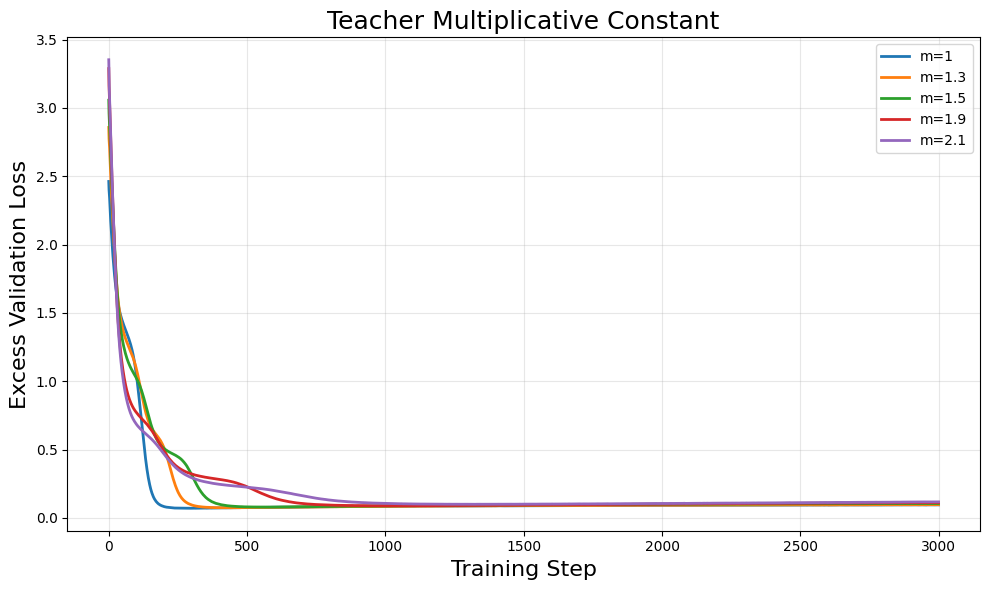

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
groups = df.groupby(["_run_name", "cfg.teacher.multiplicative_constant"], dropna=False)[
    ["val_loss", "teacher_val_loss"]
]

for (_, m_value), data in sorted(groups, key=lambda item: item[0][1]):
    teacher_val_loss = data["teacher_val_loss"].dropna().unique()[0]
    ax.plot(data["val_loss"].to_numpy() - teacher_val_loss, label=f"m={m_value:g}", linewidth=2)

ax.set_xlabel("Training Step", fontsize=16)
ax.set_ylabel("Excess Validation Loss", fontsize=16)
ax.set_title("Teacher Multiplicative Constant", fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(output_path("multiplicative-constant-excess-loss.pdf"), bbox_inches="tight", dpi=300)
else:
    plt.show()
